[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/15_ordinary_differential_equations/first_principles.ipynb)

# Module 15 — Ordinary Differential Equations

## 1. Why This Module Exists

Integral calculus answers one question: given a rate $g(t)$ that depends only on the clock, what is the accumulated state?

$$
y(t) = y(t_0) + \int_{t_0}^{t} g(s) \, ds
$$

Almost nothing in nature is described that way. The rate at which a quantity changes is normally a function of the quantity itself.

- A decaying isotope loses mass in proportion to the mass still present: $\dot{y} = -ky$.
- A spring pulls back in proportion to how far it is stretched, and a damper resists in proportion to how fast it moves: $m\ddot{x} + c\dot{x} + kx = 0$.
- Gradient descent, taken to vanishing step size, moves downhill in the loss landscape it is currently standing on: $\dot{w} = -\nabla L(w)$.
- The hidden state of a residual network is updated by a function of that same hidden state: $h_{l+1} = h_l + f(h_l, \theta_l)$.

Each of these is an **ordinary differential equation**: a relation between an unknown function of one variable and its derivatives. The integral above is the degenerate case in which the right-hand side happens to ignore $y$.

The whole module exists to answer three questions that the integral formula never had to face.

**Does a trajectory exist, and is it the only one?** When the rate depends on the state, one cannot simply integrate. The answer is Theorem 4.1, the Picard–Lindelöf theorem, and it is the theorem this module is named after. It says that a Lipschitz right-hand side buys local existence *and* uniqueness, and that dropping Lipschitz costs uniqueness immediately.

**When can the trajectory be written down?** A short list of structures — separable, linear, exact, constant-coefficient, linear-with-constant-matrix — admits closed-form solutions. Theorems 4.4 through 4.9 are that list. Everything else needs the third question.

**What can be said when it cannot be written down?** Fixed points, linearization, the trace–determinant classification, Lyapunov functions and conserved quantities describe the shape of a flow that has no formula (Theorems 4.10 to 4.13), and one-step numerical methods approximate it with a quantified error and a quantified stability limit (Theorem 4.14).

The prerequisites are exactly the tools these three questions consume: the fundamental theorem of calculus from [calculus/05](../05_indefinite_and_definite_integrals/), Taylor remainders from [calculus/09](../09_taylor_and_power_series/), and eigen-decomposition and Jordan form from [linear_algebra/07](../../linear_algebra/07_canonical_forms_and_svd/).

## 2. Intuition

An ODE $\dot{y} = f(t,y)$ does not hand you a curve. It hands you a **direction at every point of the plane**: at $(t,y)$, the slope of any solution passing through that point must be $f(t,y)$. Draw a short segment of that slope at a grid of points and you have a *slope field*, a diagram of every constraint the equation imposes.

A solution is then a curve that is everywhere tangent to the field. This one picture makes the module's central facts visible before any of them is proved.

**Existence** is the statement that you can always keep walking. Standing at $(t_0, y_0)$ with a continuous field, you always have a direction to step in, so a curve starts.

**Uniqueness** is the statement that two curves never cross. If the field's dependence on $y$ is Lipschitz — the slope cannot change faster than a fixed multiple of the vertical distance you moved — then two solutions that are close stay close, and two that agree at one instant agree forever. Where the Lipschitz bound fails, the field can funnel infinitely many curves through a single point.

**Autonomy** is the statement that the field does not drift. If $f$ does not depend on $t$, then the picture is the same at every time, and the entire long-run behaviour is decided by where the field vanishes (fixed points) and which way it points nearby.

**Numerics** is the statement that you may take finite steps instead of infinitesimal ones. Read the slope where you are, walk in a straight line for time $h$, read again. That is Euler's method, and its error is exactly the amount the true field turned during the step.

The figure below draws the slope field of $\dot{y} = y - t^2$ together with three exact solutions. The curves nest without touching, which is uniqueness made visible; they all bend to match the field, which is the ODE itself.

**Setup.** The preamble below fixes plotting defaults, the single random generator `rng` used everywhere in this notebook, and the print precision. Nothing else in the notebook seeds randomness.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy.linalg import expm
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import sympy as sp

print("preamble ready")

preamble ready


The preamble ran; every later cell reuses these settings and `rng`.

**Figure 1 (Section 2).** The slope field of $\dot{y} = y - t^2$ with three exact solutions. The general solution is $y(t) = Ce^{t} + t^2 + 2t + 2$, which is verified symbolically inside the cell before it is drawn, so the curves are the true integral curves and not a numerical approximation.

symbolic check: y = C e^t + t^2 + 2t + 2 solves y' = y - t^2


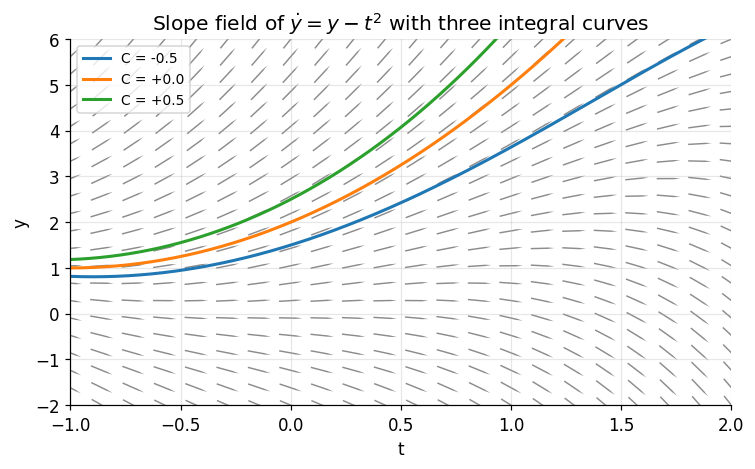

In [2]:
# Verify the closed form symbolically before plotting it.
_t, _C = sp.symbols("t C")
_y = _C * sp.exp(_t) + _t**2 + 2 * _t + 2
assert sp.simplify(sp.diff(_y, _t) - (_y - _t**2)) == 0
print("symbolic check: y = C e^t + t^2 + 2t + 2 solves y' = y - t^2")

def field(t, y):
    return y - t**2

T, Y = np.meshgrid(np.linspace(-1.0, 2.0, 22), np.linspace(-2.0, 6.0, 22))
S = field(T, Y)
norm = np.hypot(np.ones_like(S), S)
U, V = 1.0 / norm, S / norm

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.quiver(T, Y, U, V, color="0.55", angles="xy", scale=28, width=0.0022,
          headwidth=0, headlength=0, pivot="mid")

ts = np.linspace(-1.0, 2.0, 400)
for C, color in zip((-0.5, 0.0, 0.5), ("C0", "C1", "C2")):
    ax.plot(ts, C * np.exp(ts) + ts**2 + 2 * ts + 2, color=color, lw=2.0,
            label=f"C = {C:+.1f}")

ax.set_xlim(-1.0, 2.0)
ax.set_ylim(-2.0, 6.0)
ax.set_xlabel("t")
ax.set_ylabel("y")
ax.set_title(r"Slope field of $\dot{y} = y - t^2$ with three integral curves")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

Every grey segment is the slope the equation demands at that point, and each coloured curve is tangent to the field at every one of its points. The three curves never touch: through each point of the plane passes exactly one of them, which is the geometric content of Theorem 4.1. The field is steepest where $\lvert y - t^2 \rvert$ is largest, and flat exactly along the parabola $y = t^2$, where the right-hand side vanishes.

## 3. Definitions

### Definition 3.1 (ODE, order, initial value problem)

Let $\Omega \subseteq \mathbb{R} \times \mathbb{R}^n$ be open and let $f : \Omega \to \mathbb{R}^n$. A **first-order system of ordinary differential equations** is

$$
\frac{dy}{dt} = f(t, y), \qquad y : I \to \mathbb{R}^n, \quad I \subseteq \mathbb{R} \text{ an interval}.
$$

A **solution on $I$** is a differentiable $y$ with $(t, y(t)) \in \Omega$ and $y'(t) = f(t, y(t))$ for every $t \in I$. Pairing the equation with a prescribed state at one instant gives an **initial value problem (IVP)**:

$$
y'(t) = f(t, y(t)), \qquad y(t_0) = y_0 .
$$

A scalar equation of **order** $m$, $y^{(m)} = F(t, y, y', \dots, y^{(m-1)})$, becomes a first-order system of dimension $m$ under $u = (y, y', \dots, y^{(m-1)})$, so nothing is lost by treating only first-order systems. The system is **autonomous** if $f$ does not depend on $t$, and **linear** if $f(t,y) = A(t)y + b(t)$.

### Definition 3.2 (Lipschitz continuity in the state variable)

$f$ is **Lipschitz continuous in $y$** with constant $L \ge 0$ on $D \subseteq \Omega$ if

$$
\lVert f(t, y_1) - f(t, y_2) \rVert \le L \lVert y_1 - y_2 \rVert \qquad \text{for all } (t, y_1), (t, y_2) \in D .
$$

If $\partial f / \partial y$ exists and is bounded in operator norm by $L$ on a convex $D$, the mean value inequality gives this condition; the converse is false, so Lipschitz is the weaker and therefore the right hypothesis.

### Definition 3.3 (Wronskian)

For $y_1, y_2 : I \to \mathbb{R}$ differentiable, the **Wronskian** is

$$
W(y_1, y_2)(t) = \det \begin{pmatrix} y_1(t) & y_2(t) \\ y_1'(t) & y_2'(t) \end{pmatrix} = y_1(t) y_2'(t) - y_1'(t) y_2(t).
$$

### Definition 3.4 (Matrix exponential)

For $A \in \mathbb{R}^{n \times n}$ and $t \in \mathbb{R}$,

$$
e^{At} = \sum_{k=0}^{\infty} \frac{t^k A^k}{k!},
$$

the series being taken entrywise; Theorem 4.9(i) shows it converges for every $A$ and $t$.

### Definition 3.5 (Fixed point, hyperbolicity, stability)

For the autonomous system $\dot{x} = F(x)$ with $F : U \subseteq \mathbb{R}^n \to \mathbb{R}^n$, a point $x^\ast$ with $F(x^\ast) = 0$ is a **fixed point** (equilibrium). It is:

- **Lyapunov stable** if for every $\varepsilon \gt 0$ there is $\delta \gt 0$ with $\lVert x(0) - x^\ast \rVert \lt \delta \implies \lVert x(t) - x^\ast \rVert \lt \varepsilon$ for all $t \ge 0$;
- **asymptotically stable** if it is Lyapunov stable and additionally $x(t) \to x^\ast$;
- **hyperbolic** if every eigenvalue of the Jacobian $J_F(x^\ast)$ has non-zero real part.

### Definition 3.6 (Lyapunov function)

Let $x^\ast = 0$ be a fixed point of $\dot{x} = F(x)$ and $U \ni 0$ open. A function $V \in C^1(U, \mathbb{R})$ is a **Lyapunov function** if $V(0) = 0$, $V(x) \gt 0$ on $U \setminus \lbrace 0 \rbrace$, and the **orbital derivative**

$$
\dot{V}(x) := \nabla V(x) \cdot F(x)
$$

satisfies $\dot{V} \le 0$ on $U$. It is **strict** if $\dot{V}(x) \lt 0$ on $U \setminus \lbrace 0 \rbrace$.

### Definition 3.7 (First integral)

A function $H \in C^1(U, \mathbb{R})$ is a **first integral** (conserved quantity) of $\dot{x} = F(x)$ if $\nabla H(x) \cdot F(x) = 0$ for all $x \in U$; equivalently $t \mapsto H(x(t))$ is constant along every solution in $U$.

### Definition 3.8 (One-step method, order, region of absolute stability)

A **one-step method** with step $h$ is a map $y_{n+1} = \Psi_h(t_n, y_n)$. It has **order** $p$ if the global error on a fixed interval satisfies $\max_n \lVert y_n - y(t_n) \rVert = O(h^p)$ as $h \to 0$. Applied to the scalar test equation $\dot{y} = \lambda y$ it reduces to $y_{n+1} = R(z) y_n$ with $z = \lambda h$; $R$ is the **stability function**, and

$$
\mathcal{S} = \lbrace z \in \mathbb{C} : \lvert R(z) \rvert \le 1 \rbrace
$$

is the **region of absolute stability**. A method is **A-stable** if $\mathcal{S}$ contains the whole open left half-plane.

## 4. Main Results

### Theorem 4.1 (Picard–Lindelöf: local existence and uniqueness)

Let $t_0 \in \mathbb{R}$, $y_0 \in \mathbb{R}^n$, $a, b \gt 0$, and

$$
D = \lbrace (t, y) : \lvert t - t_0 \rvert \le a, \ \lVert y - y_0 \rVert \le b \rbrace .
$$

Assume

1. $f : D \to \mathbb{R}^n$ is **continuous**;
2. $f$ is **Lipschitz in $y$ on $D$** with constant $L$ (Definition 3.2);
3. $M := \max_{D} \lVert f \rVert$ is finite, and $\alpha := \min(a, b/M)$.

Then the IVP $y' = f(t,y)$, $y(t_0) = y_0$ has **exactly one** solution on $I_\alpha = [t_0 - \alpha, t_0 + \alpha]$, and the Picard iterates $y_{k+1}(t) = y_0 + \int_{t_0}^{t} f(s, y_k(s)) \, ds$ converge to it uniformly on $I_\alpha$ with

$$
\boxed{\ \max_{t \in I_\alpha} \lVert y_k(t) - y(t) \rVert \ \le \ \frac{M}{L} \frac{(L\alpha)^{k+1}}{(k+1)!} e^{L\alpha}\ }
$$

**Interpretation.** The bound says the Picard iteration converges *faster than any geometric rate*: the factorial in the denominator eventually beats every power of $L\alpha$. The consequence is that the solution is not merely proved to exist by an abstract argument — it is the limit of an explicit sequence of integrals, each computable from the previous one, with an error you can bound before running a single step.

Why each hypothesis is needed:

- **Continuity of $f$** makes $s \mapsto f(s, y(s))$ integrable, so the integral form of the equation is meaningful at all; without it there is no reason for a solution to be $C^1$.
- **Lipschitz in $y$** is what forbids two solutions from separating: it converts the difference of two trajectories into a differential inequality that only $0$ satisfies. Theorem 4.3 shows existence survives without it and uniqueness does not.
- **$\alpha \le b/M$** keeps the iterates inside $D$, where the two hypotheses above are assumed to hold; on a larger interval the iterates could leave the rectangle and the estimates would be about a region where nothing was assumed.

### Theorem 4.2 (Grönwall's inequality, integral form)

Let $\varphi : [t_0, t_1] \to [0, \infty)$ be continuous and suppose there are constants $c \ge 0$, $L \ge 0$ with

$$
\varphi(t) \le c + L \int_{t_0}^{t} \varphi(s) \, ds \qquad \text{for all } t \in [t_0, t_1] .
$$

Then $\varphi(t) \le c \, e^{L (t - t_0)}$ on $[t_0, t_1]$. In particular $c = 0$ forces $\varphi \equiv 0$.

*Continuity is needed so that the integral exists and the auxiliary function below is differentiable; non-negativity of $L$ is needed so that multiplying the inequality by $e^{-L(t-t_0)}$ preserves its direction.*

### Theorem 4.3 (Peano existence — cited, not proved here)

If $f$ is continuous on $D$ (no Lipschitz assumption), the IVP has **at least one** solution on $\lvert t - t_0 \rvert \le \alpha$, but uniqueness may fail.

The proof replaces the contraction argument by the Arzelà–Ascoli theorem applied to a family of Euler polygons, which needs a compactness theorem in $C(I_\alpha, \mathbb{R}^n)$ that this module does not develop. Reference: Teschl, *Ordinary Differential Equations and Dynamical Systems*, GSM 140, §2.6, Theorem 2.19. The sharp special case *is* proved here: hypothesis 2 of Theorem 4.1 is exactly what uniqueness costs, and Section 7 exhibits the standard failure $\dot{y} = y^{2/3}$, $y(0) = 0$, whose solutions include both $y \equiv 0$ and $y(t) = t^3/27$.

### Theorem 4.4 (First-order linear equations: integrating factor)

Let $p, q$ be continuous on an interval $I \ni x_0$ and let $\mu(x) = \exp\left(\int_{x_0}^{x} p(s) \, ds\right)$. Then every solution of $y' + p(x) y = q(x)$ on $I$ is given by

$$
\boxed{\ y(x) = \frac{1}{\mu(x)} \left( \mu(x_0) y(x_0) + \int_{x_0}^{x} \mu(s) q(s) \, ds \right)\ }
$$

**Interpretation.** Multiplying by $\mu$ turns a sum of two unrelated terms into the derivative of a single product, so the equation collapses to one integration. The consequence is that first-order linear equations are *always* solvable in quadrature on any interval where $p$ and $q$ are continuous — no extra hypothesis, no case analysis, and the solution is unique because the formula leaves only $y(x_0)$ free.

*Continuity of $p$ is needed for $\mu$ to be defined and $C^1$; continuity of $q$ is needed for the second integral to exist. Nothing else is assumed, and $\mu \gt 0$ everywhere means the division is always legal.*

### Theorem 4.5 (Exactness criterion)

Let $M, N \in C^1(D)$ on a simply connected open $D \subseteq \mathbb{R}^2$. There exists $\Phi \in C^2(D)$ with $\Phi_x = M$ and $\Phi_y = N$ — so that $M \, dx + N \, dy = 0$ has the implicit solutions $\Phi(x,y) = C$ — **if and only if**

$$
\boxed{\ \frac{\partial M}{\partial y} = \frac{\partial N}{\partial x} \quad \text{on } D.\ }
$$

**Interpretation.** The condition is the equality of mixed partials of a potential that may or may not exist; it says a planar vector field is a gradient exactly when its "curl" vanishes. The consequence is a decision procedure: differentiate twice, compare, and either integrate to a potential or hunt for an integrating factor.

*$C^1$ is needed for Clairaut's theorem in one direction; simple connectedness is needed in the other, since on a punctured domain the closed field $(-y \, dx + x \, dy)/(x^2+y^2)$ has no single-valued potential.*

### Theorem 4.6 (Constant-coefficient second-order equations)

Let $a \ne 0$ and consider $a y'' + b y' + c y = 0$ with characteristic polynomial $a r^2 + b r + c$ and discriminant $\Delta = b^2 - 4ac$. A basis of the real solution space is

| case | roots | basis |
| :--- | :--- | :--- |
| $\Delta \gt 0$ | $r_1 \ne r_2$ real | $e^{r_1 t}, \ e^{r_2 t}$ |
| $\Delta = 0$ | $r = -b/(2a)$ double | $e^{rt}, \ t e^{rt}$ |
| $\Delta \lt 0$ | $\alpha \pm i\beta$ | $e^{\alpha t}\cos\beta t, \ e^{\alpha t}\sin\beta t$ |

and the solution space is two-dimensional over $\mathbb{R}$.

*$a \ne 0$ is needed for the equation to be second order at all; constancy of $a,b,c$ is what makes $e^{rt}$ an eigenfunction of the operator, and with variable coefficients the exponential ansatz fails.*

### Theorem 4.7 (Abel's identity and the Wronskian dichotomy)

Let $p, q$ be continuous on an interval $I$ and let $y_1, y_2$ solve $y'' + p(t) y' + q(t) y = 0$ on $I$. Then $W = W(y_1,y_2)$ satisfies $W' = -p W$, hence for any $t_0 \in I$

$$
\boxed{\ W(t) = W(t_0) \exp\left( - \int_{t_0}^{t} p(s) \, ds \right).\ }
$$

**Interpretation.** The Wronskian obeys a first-order linear equation of its own, whose solution is an exponential and therefore never changes sign. The consequence is a dichotomy: for solutions of a *single* second-order linear equation with continuous coefficients, either $W$ vanishes identically on $I$ — and then $y_1, y_2$ are linearly dependent — or $W$ vanishes nowhere and $\lbrace y_1, y_2 \rbrace$ is a basis. Checking one point settles the whole interval.

*Both $y_1$ and $y_2$ must solve the **same** equation with **continuous** coefficients. Drop that and the dichotomy is false: $y_1(t) = t^3$ and $y_2(t) = \lvert t \rvert^3$ on $[-1,1]$ have $W \equiv 0$ and are linearly independent.*

### Theorem 4.8 (Variation of parameters)

Let $y_1, y_2$ be a basis of solutions of $y'' + p y' + q y = 0$ on $I$ with $p, q, g$ continuous and $W = W(y_1,y_2)$ (nowhere zero by Theorem 4.7). Then a particular solution of $y'' + p y' + q y = g$ is

$$
\boxed{\ y_p(t) = -y_1(t) \int \frac{y_2(t) g(t)}{W(t)} \, dt + y_2(t) \int \frac{y_1(t) g(t)}{W(t)} \, dt\ }
$$

**Interpretation.** The homogeneous basis is reused with the constants promoted to functions, and the two unknown functions are pinned down by one structural constraint plus the equation itself. The consequence is that the *entire* inhomogeneous problem reduces to two integrals, for **any** continuous forcing $g$ — unlike undetermined coefficients, which needs $g$ to be an exponential-polynomial.

*Continuity of $g$ makes the integrands integrable; $W \ne 0$ (guaranteed by Theorem 4.7 once $y_1,y_2$ is a basis) makes the $2 \times 2$ system for $u_1', u_2'$ solvable.*

### Theorem 4.9 (Matrix exponential)

Let $A, B \in \mathbb{R}^{n \times n}$. Then

1. the series of Definition 3.4 converges absolutely, and uniformly on $\lvert t \rvert \le T$ for every $T$;
2. $\dfrac{d}{dt} e^{At} = A e^{At} = e^{At} A$;
3. $e^{At}$ is invertible with $(e^{At})^{-1} = e^{-At}$;
4. if $AB = BA$ then $e^{A+B} = e^{A} e^{B}$ — commuting is **sufficient but not necessary**;
5. the IVP $\dot{x} = Ax$, $x(0) = x_0$ has the unique solution

$$
\boxed{\ x(t) = e^{At} x_0 .\ }
$$

**Interpretation.** Every constant-coefficient linear system has one closed-form solution operator, and it is a genuine matrix function of $A$ rather than a formal symbol. The consequence is that the qualitative behaviour of $\dot x = Ax$ is read off the spectrum of $A$: $\operatorname{Re}\lambda \lt 0$ for all eigenvalues gives decay, any $\operatorname{Re}\lambda \gt 0$ gives growth, and a defective eigenvalue contributes the polynomial factors $t^k e^{\lambda t}$ from the nilpotent part.

*Statement 4 needs $AB = BA$ because the binomial expansion of $(A+B)^k$ used in the proof is only valid for commuting matrices. Statements 1–3 and 5 need nothing beyond $A$ being a fixed square matrix.*

### Theorem 4.10 (Trace–determinant classification of planar linear systems)

Let $A \in \mathbb{R}^{2\times 2}$ with $\tau = \operatorname{tr} A$, $\delta = \det A$, so the eigenvalues are $\lambda_{1,2} = \tfrac{1}{2}\left(\tau \pm \sqrt{\tau^2 - 4\delta}\right)$. For $\dot{x} = Ax$ the origin is:

| region | eigenvalues | type |
| :--- | :--- | :--- |
| $\delta \lt 0$ | real, opposite signs | saddle (unstable) |
| $\delta \gt 0$, $\tau^2 - 4\delta \ge 0$, $\tau \lt 0$ | real, both negative | stable node |
| $\delta \gt 0$, $\tau^2 - 4\delta \ge 0$, $\tau \gt 0$ | real, both positive | unstable node |
| $\delta \gt 0$, $\tau^2 - 4\delta \lt 0$, $\tau \lt 0$ | complex, $\operatorname{Re} \lt 0$ | stable spiral |
| $\delta \gt 0$, $\tau^2 - 4\delta \lt 0$, $\tau \gt 0$ | complex, $\operatorname{Re} \gt 0$ | unstable spiral |
| $\delta \gt 0$, $\tau = 0$ | $\pm i\sqrt{\delta}$ | centre (non-hyperbolic) |

The origin is asymptotically stable **iff** $\tau \lt 0$ and $\delta \gt 0$.

*The classification uses only that $\tau$ and $\delta$ determine the characteristic polynomial of a $2 \times 2$ matrix; it says nothing about $n \ge 3$, where two invariants no longer determine the spectrum.*

### Theorem 4.11 (Hartman–Grobman — cited, not proved here)

If $x^\ast$ is a **hyperbolic** fixed point of $\dot{x} = F(x)$ with $F \in C^1$, then there is a neighbourhood of $x^\ast$ and a homeomorphism carrying orbits of the nonlinear flow onto orbits of $\dot{\eta} = J_F(x^\ast)\eta$, preserving time direction.

The proof constructs the conjugating homeomorphism as a fixed point in a space of bounded continuous maps and is a genuinely separate development. Reference: Teschl, *Ordinary Differential Equations and Dynamical Systems*, GSM 140, §9.2, Theorem 9.9. The special case this module proves in full is the *linear* one: Theorem 4.10 classifies $\dot{x} = Ax$ completely, and Theorem 4.12 supplies the nonlinear conclusion at non-hyperbolic points where Hartman–Grobman says nothing.

### Theorem 4.12 (Lyapunov's direct method)

Let $x^\ast = 0$ be a fixed point of $\dot{x} = F(x)$, $F$ continuous on an open $U \ni 0$, and let $V$ be a Lyapunov function on $U$ (Definition 3.6). Then $0$ is Lyapunov stable. If $V$ is strict, $0$ is asymptotically stable; if in addition $U = \mathbb{R}^n$ and $V$ is radially unbounded ($V(x) \to \infty$ as $\lVert x \rVert \to \infty$), $0$ is globally asymptotically stable.

*Positive definiteness of $V$ is what makes sublevel sets of $V$ shrink to the origin; $\dot V \le 0$ is what makes them forward-invariant; radial unboundedness is what stops a sublevel set from being unbounded, which would let a trajectory escape while $V$ still decreases.*

### Theorem 4.13 (Lotka–Volterra: first integral and closed orbits)

For $\alpha,\beta,\gamma,\delta \gt 0$ consider on the open quadrant $Q = \lbrace x \gt 0, y \gt 0 \rbrace$

$$
\dot{x} = x(\alpha - \beta y), \qquad \dot{y} = y(\delta x - \gamma).
$$

Then

$$
\boxed{\ H(x,y) = \delta x - \gamma \ln x + \beta y - \alpha \ln y\ }
$$

is a first integral, $H$ has a unique critical point at the coexistence equilibrium $(x^\ast, y^\ast) = (\gamma/\delta, \alpha/\beta)$, which is its strict global minimum on $Q$, and **every** orbit in $Q \setminus \lbrace (x^\ast,y^\ast) \rbrace$ is a closed curve encircling $(x^\ast, y^\ast)$; every such solution is periodic.

**Interpretation.** The linearisation at $(x^\ast, y^\ast)$ has $\tau = 0$, so Theorem 4.10 predicts a centre and Theorem 4.11 refuses to transfer that prediction to the nonlinear system. $H$ settles it without linearising: the orbits are exactly its level sets. The consequence is that predator–prey populations neither converge to coexistence nor spiral out — they cycle forever, with an amplitude fixed entirely by the initial condition.

*Strict positivity of all four parameters is needed for $(x^\ast, y^\ast)$ to lie in $Q$; restricting to $Q$ is needed because $\ln x$ and $\ln y$ are undefined on the axes — which are themselves invariant, so no orbit in $Q$ ever reaches them.*

### Theorem 4.14 (Order and absolute stability of Euler and RK4)

Let $f$ be continuous in $t$ and Lipschitz in $y$ with constant $L$ on a strip containing the exact solution on $[t_0, t_0 + T]$.

1. **Forward Euler** $y_{n+1} = y_n + h f(t_n, y_n)$ has order $1$; its stability function is $R(z) = 1 + z$, so $\mathcal{S}$ is the closed disc of radius $1$ about $-1$.
2. **Backward Euler** $y_{n+1} = y_n + h f(t_{n+1}, y_{n+1})$ has order $1$ and $R(z) = (1-z)^{-1}$, so $\mathcal{S} = \lbrace \lvert 1 - z \rvert \ge 1 \rbrace \supset \lbrace \operatorname{Re} z \lt 0 \rbrace$: it is A-stable.
3. **Classical RK4** has order $4$ and

$$
\boxed{\ R_{\mathrm{RK4}}(z) = 1 + z + \frac{z^2}{2} + \frac{z^3}{6} + \frac{z^4}{24},\ }
$$

the degree-4 Taylor polynomial of $e^z$; $\mathcal{S}$ is bounded, and on the negative real axis $\mathcal{S} \cap \mathbb{R} = [-2.7853, 0]$.

**Interpretation.** Order controls accuracy as $h \to 0$; the stability region controls which $h$ are usable at all. The consequence is the stiffness trap: for $\dot y = \lambda y$ with $\lambda = -10^{6}$ the exact solution is boringly smooth, yet explicit Euler needs $h \le 2 \times 10^{-6}$ purely to avoid blow-up, while backward Euler has no step restriction whatsoever.

*Lipschitz continuity of $f$ is what converts the per-step truncation error into a global error bound through the discrete Grönwall lemma; without it a consistent method need not converge.*

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, Picard–Lindelöf)

Throughout write $I_\alpha = [t_0 - \alpha, t_0 + \alpha]$ and

$$
S = \lbrace u \in C(I_\alpha, \mathbb{R}^n) : \lVert u(t) - y_0 \rVert \le b \text{ for all } t \in I_\alpha \rbrace .
$$

**Step 1 — the differential equation is equivalent to an integral equation.**
If $y \in C^1(I_\alpha)$ solves the IVP, then $s \mapsto f(s, y(s))$ is continuous, and integrating $y' = f(s,y)$ from $t_0$ to $t$ using the fundamental theorem of calculus gives

$$
y(t) = y_0 + \int_{t_0}^{t} f(s, y(s)) \, ds. \tag{5.1}
$$

Conversely, if a continuous $y$ satisfies (5.1), the integrand is continuous, so the right side is $C^1$ with derivative $f(t, y(t))$, and setting $t = t_0$ gives $y(t_0) = y_0$. So the two problems have exactly the same solutions, and it suffices to study the operator

$$
(Tu)(t) = y_0 + \int_{t_0}^{t} f(s, u(s)) \, ds .
$$

**Step 2 — $T$ maps $S$ into $S$.**
For $u \in S$ the pair $(s, u(s))$ lies in $D$, so $\lVert f(s,u(s)) \rVert \le M$, and for $t \in I_\alpha$

$$
\lVert (Tu)(t) - y_0 \rVert \le \left\lvert \int_{t_0}^{t} \lVert f(s,u(s)) \rVert \, ds \right\rvert \le M \lvert t - t_0 \rvert \le M\alpha \le b ,
$$

the last step by $\alpha \le b/M$. Also $Tu$ is continuous (indeed Lipschitz with constant $M$). Hence $Tu \in S$. Starting from the constant function $y_0(t) \equiv y_0 \in S$, the whole Picard sequence $y_{k+1} = T y_k$ stays in $S$.

**Step 3 — a factorial bound on consecutive differences.**
Claim: for every $k \ge 0$ and $t \in I_\alpha$,

$$
\lVert y_{k+1}(t) - y_k(t) \rVert \le \frac{M L^{k} \lvert t - t_0 \rvert^{k+1}}{(k+1)!}. \tag{5.2}
$$

For $k = 0$, Step 2 already gives $\lVert y_1(t) - y_0 \rVert \le M\lvert t - t_0\rvert$. Assume (5.2) for $k-1$. Then, using the Lipschitz hypothesis on $D$ (legitimate because both iterates lie in $S$),

$$
\lVert y_{k+1}(t) - y_k(t) \rVert
\le \left\lvert \int_{t_0}^{t} \lVert f(s, y_k(s)) - f(s, y_{k-1}(s)) \rVert \, ds \right\rvert
\le L \left\lvert \int_{t_0}^{t} \lVert y_k(s) - y_{k-1}(s) \rVert \, ds \right\rvert ,
$$

and inserting the inductive bound,

$$
\le L \left\lvert \int_{t_0}^{t} \frac{M L^{k-1} \lvert s - t_0 \rvert^{k}}{k!} \, ds \right\rvert
= \frac{M L^{k} \lvert t - t_0 \rvert^{k+1}}{(k+1)!},
$$

which is (5.2). The induction is complete.

**Step 4 — uniform convergence.**
By (5.2), $\max_{I_\alpha} \lVert y_{k+1} - y_k \rVert \le \frac{M}{L}\frac{(L\alpha)^{k+1}}{(k+1)!}$, and

$$
\sum_{k \ge 0} \frac{M}{L}\frac{(L\alpha)^{k+1}}{(k+1)!} = \frac{M}{L}\left(e^{L\alpha} - 1\right) \lt \infty .
$$

By the Weierstrass $M$-test the telescoping series $y_0 + \sum_{k\ge 0}(y_{k+1} - y_k)$ converges uniformly on $I_\alpha$; call the limit $y$. A uniform limit of continuous functions is continuous, and $S$ is closed under uniform limits, so $y \in S$. Summing the tail of the same series gives the stated rate,

$$
\max_{I_\alpha}\lVert y - y_k \rVert \le \sum_{j \ge k} \frac{M}{L}\frac{(L\alpha)^{j+1}}{(j+1)!} \le \frac{M}{L}\frac{(L\alpha)^{k+1}}{(k+1)!} \, e^{L\alpha},
$$

using $\frac{(k+1)!}{(j+1)!} \le \frac{1}{(j-k)!}$ for $j \ge k$ and resumming.

**Step 5 — the limit solves the equation.**
Lipschitz continuity gives $\lVert f(s,y_k(s)) - f(s,y(s)) \rVert \le L \lVert y_k(s) - y(s)\rVert$, which tends to $0$ uniformly in $s$. Therefore

$$
\left\lVert \int_{t_0}^{t} f(s,y_k(s))\, ds - \int_{t_0}^{t} f(s,y(s))\, ds \right\rVert \le L\alpha \max_{I_\alpha}\lVert y_k - y \rVert \to 0 ,
$$

so passing to the limit in $y_{k+1} = T y_k$ yields $y = Ty$, i.e. (5.1). By Step 1, $y$ solves the IVP on $I_\alpha$. Existence is proved.

**Step 6 — uniqueness.**
Let $y, z$ both solve the IVP on $I_\alpha$ with values in $D$, and set $\varphi(t) = \lVert y(t) - z(t) \rVert$, continuous with $\varphi(t_0) = 0$. Subtracting the two copies of (5.1) and using Lipschitz,

$$
\varphi(t) \le \left\lvert \int_{t_0}^{t} \lVert f(s,y(s)) - f(s,z(s)) \rVert \, ds \right\rvert \le L \left\lvert \int_{t_0}^{t} \varphi(s)\, ds \right\rvert .
$$

On $[t_0, t_0+\alpha]$ this is the hypothesis of Theorem 4.2 with $c = 0$, so $\varphi \equiv 0$ there; on $[t_0-\alpha, t_0]$ the same argument applies to $\tilde\varphi(t) = \varphi(2t_0 - t)$. Hence $y = z$ on $I_\alpha$. $\blacksquare$

Nothing in Steps 1–6 assumes what is being proved: existence is produced by an explicit convergent sequence, and uniqueness by Theorem 4.2, which is proved below from the fundamental theorem of calculus alone.

### Proof 5.2 (of Theorem 4.2, Grönwall)

Let $\Psi(t) = c + L\int_{t_0}^{t}\varphi(s)\,ds$. Since $\varphi$ is continuous, $\Psi \in C^1$ with $\Psi'(t) = L\varphi(t) \le L\Psi(t)$, using the hypothesis $\varphi \le \Psi$ and $L \ge 0$. Therefore

$$
\frac{d}{dt}\left[ e^{-L(t-t_0)}\Psi(t) \right] = e^{-L(t-t_0)}\left( \Psi'(t) - L\Psi(t) \right) \le 0 ,
$$

so $e^{-L(t-t_0)}\Psi(t) \le \Psi(t_0) = c$, i.e. $\Psi(t) \le c e^{L(t-t_0)}$. Combining with $\varphi \le \Psi$ gives the claim. With $c = 0$ we get $0 \le \varphi(t) \le 0$. $\blacksquare$

### Proof 5.3 (of Theorem 4.4, integrating factor)

Seek $\mu \gt 0$ making the left side an exact derivative:

$$
\mu y' + \mu p y \stackrel{!}{=} (\mu y)' = \mu y' + \mu' y \iff \mu' = p \mu .
$$

That scalar equation is separable, and $\mu(x) = \exp\left(\int_{x_0}^{x} p\right)$ is a positive solution. Multiplying $y' + py = q$ by this $\mu$ gives $(\mu y)' = \mu q$; integrating from $x_0$ to $x$ and dividing by $\mu(x) \gt 0$ gives the boxed formula. Conversely every function of that form is $C^1$ and satisfies the equation by differentiating the product, so the formula captures all solutions. $\blacksquare$

### Proof 5.4 (of Theorem 4.5, exactness)

($\Rightarrow$) If $\Phi_x = M$ and $\Phi_y = N$ with $M, N \in C^1$, then $\Phi \in C^2$ and Clairaut's theorem gives $M_y = \Phi_{xy} = \Phi_{yx} = N_x$.

($\Leftarrow$) Assume $M_y = N_x$ on the simply connected $D$. Fix $(x_0,y_0) \in D$ and define $\Phi$ as the line integral of $M \, dx + N \, dy$ along any path in $D$ from $(x_0,y_0)$ to $(x,y)$. The condition $M_y = N_x$ says the field is closed, and on a simply connected domain a closed $C^1$ field is exact, so the integral is path-independent and $\Phi$ is well defined with $\Phi_x = M$, $\Phi_y = N$. Then along any solution curve, $\frac{d}{dx}\Phi(x, y(x)) = M + N y' = 0$, so $\Phi$ is constant. $\blacksquare$

### Proof 5.5 (of Theorem 4.6, characteristic roots)

Substituting $y = e^{rt}$ into $ay'' + by' + cy = 0$ gives $e^{rt}(ar^2+br+c) = 0$, and $e^{rt} \ne 0$, so $r$ must be a characteristic root. If $\Delta \gt 0$ the two exponentials have Wronskian $(r_2-r_1)e^{(r_1+r_2)t} \ne 0$, so they are a basis by Theorem 4.7.

If $\Delta = 0$, write $r = -b/(2a)$ and look for a second solution $y_2 = v(t)e^{rt}$. Then

$$
a y_2'' + b y_2' + c y_2 = e^{rt}\left[ a v'' + (2ar + b) v' + (ar^2+br+c)v \right] = e^{rt} \, a v'' ,
$$

because $2ar + b = 0$ and $ar^2+br+c = 0$. Hence $v'' = 0$, and $v(t) = t$ gives $y_2 = te^{rt}$, whose Wronskian with $e^{rt}$ is $e^{2rt} \ne 0$.

If $\Delta \lt 0$ the roots are $\alpha \pm i\beta$ with $\beta \ne 0$, and $e^{(\alpha\pm i\beta)t}$ solve the (complex) equation. Since the coefficients are real, the real and imaginary parts $e^{\alpha t}\cos\beta t$ and $e^{\alpha t}\sin\beta t$ solve it too, and their Wronskian is $\beta e^{2\alpha t} \ne 0$.

In each case a solution is determined by $(y(t_0), y'(t_0)) \in \mathbb{R}^2$ and Theorem 4.1 makes that map injective, while the basis above makes it surjective; so the solution space has dimension exactly $2$. $\blacksquare$

### Proof 5.6 (of Theorem 4.7, Abel)

Differentiate $W = y_1y_2' - y_1'y_2$:

$$
W' = y_1'y_2' + y_1y_2'' - y_1''y_2 - y_1'y_2' = y_1y_2'' - y_1''y_2 .
$$

Both functions solve the equation, so $y_i'' = -p y_i' - q y_i$, giving

$$
W' = y_1(-py_2' - qy_2) - (-py_1' - qy_1)y_2 = -p\,(y_1y_2' - y_1'y_2) = -p\,W .
$$

This is a first-order linear equation, and Theorem 4.4 with $q \equiv 0$ gives $W(t) = W(t_0)\exp\left(-\int_{t_0}^{t} p\right)$. The exponential is strictly positive, so $W$ vanishes at one point of $I$ iff it vanishes on all of $I$. If $W(t_0) \ne 0$ the map $(c_1,c_2) \mapsto (c_1y_1+c_2y_2)$ has invertible Jacobian at $t_0$, so $y_1, y_2$ are independent; if $W \equiv 0$, then $(y_1(t_0), y_1'(t_0))$ and $(y_2(t_0), y_2'(t_0))$ are parallel, and Theorem 4.1 applied to the resulting proportional initial data forces $y_2 = \lambda y_1$. $\blacksquare$

### Proof 5.7 (of Theorem 4.8, variation of parameters)

Put $y_p = u_1y_1 + u_2y_2$. Then $y_p' = u_1y_1' + u_2y_2' + (u_1'y_1 + u_2'y_2)$. Impose the constraint

$$
u_1'y_1 + u_2'y_2 = 0 , \tag{5.3}
$$

which is a choice, not a loss: it fixes one of the two degrees of freedom in $(u_1,u_2)$. Then $y_p'' = u_1y_1'' + u_2y_2'' + u_1'y_1' + u_2'y_2'$, and substituting into the equation,

$$
u_1\underbrace{(y_1''+py_1'+qy_1)}_{=0} + u_2\underbrace{(y_2''+py_2'+qy_2)}_{=0} + u_1'y_1' + u_2'y_2' = g .
$$

Together with (5.3) this is the linear system

$$
\begin{pmatrix} y_1 & y_2 \\ y_1' & y_2' \end{pmatrix}\begin{pmatrix} u_1' \\ u_2' \end{pmatrix} = \begin{pmatrix} 0 \\ g \end{pmatrix},
$$

whose matrix has determinant $W \ne 0$. Cramer's rule gives $u_1' = -y_2g/W$ and $u_2' = y_1g/W$; integrating and substituting back gives the boxed formula. $\blacksquare$

### Proof 5.8 (of Theorem 4.9, matrix exponential)

(i) With any submultiplicative matrix norm, $\left\lVert t^kA^k/k! \right\rVert \le (\lvert t\rvert \lVert A\rVert)^k/k!$, whose sum is $e^{\lvert t\rvert\lVert A\rVert}$. Absolute convergence of a series of matrices is entrywise absolute convergence, and on $\lvert t\rvert \le T$ the majorant is the constant sequence $(T\lVert A\rVert)^k/k!$, so the $M$-test gives uniform convergence.

(ii) A power series in $t$ with infinite radius of convergence may be differentiated term by term on every bounded interval, by (i). Hence

$$
\frac{d}{dt}\sum_{k\ge 0}\frac{t^kA^k}{k!} = \sum_{k \ge 1}\frac{t^{k-1}A^{k}}{(k-1)!} = A\sum_{m\ge 0}\frac{t^mA^m}{m!} = Ae^{At},
$$

and pulling $A$ out on the right instead gives $e^{At}A$.

(iii) and (iv). If $AB = BA$ then $(A+B)^k = \sum_{j}\binom{k}{j}A^jB^{k-j}$, and the Cauchy product of the two absolutely convergent series $e^Ae^B$ is exactly $\sum_k (A+B)^k/k!$. Taking $B = -A$ (which commutes with $A$) gives $e^{At}e^{-At} = e^{0} = I$, so $e^{At}$ is invertible with the stated inverse. The converse of (iv) fails, and a concrete witness settles it: for any $b \ne 0$ put

$$
A = 2\pi i \begin{pmatrix} 1 & 0 \\ 0 & -1\end{pmatrix}, \qquad B = 2\pi i \begin{pmatrix} 1 & b \\ 0 & -1\end{pmatrix}.
$$

Each of $A$, $B$ and $A+B$ is $2\pi i$ times a diagonalisable matrix with integer eigenvalues ($\pm 1$, $\pm 1$ and $\pm 2$ respectively), so $e^{A} = e^{B} = e^{A+B} = I$ and the identity holds, while $AB - BA = -4\pi^2\left(\begin{smallmatrix} 0 & 2b \\ 0 & 0\end{smallmatrix}\right) \ne 0$. Section 7 checks both this witness and a pair for which the identity genuinely fails.

(v) Let $x(t) = e^{At}x_0$. By (ii), $\dot x = Ae^{At}x_0 = Ax$, and $x(0) = x_0$. For uniqueness, note $f(t,x) = Ax$ is Lipschitz in $x$ with constant $\lVert A\rVert_{\mathrm{op}}$ on all of $\mathbb{R}^n$, so Theorem 4.1 applies on every rectangle; alternatively, if $z$ is any solution, $\frac{d}{dt}\left(e^{-At}z\right) = -Ae^{-At}z + e^{-At}Az = 0$ by (ii), so $e^{-At}z$ is constant and $z(t) = e^{At}z(0)$. $\blacksquare$

### Proof 5.9 (of Theorem 4.10, trace–determinant)

The characteristic polynomial of a $2\times 2$ matrix is $\lambda^2 - \tau\lambda + \delta$, so $\lambda_{1,2} = \tfrac12(\tau \pm \sqrt{\tau^2-4\delta})$, $\lambda_1\lambda_2 = \delta$ and $\lambda_1+\lambda_2 = \tau$.

If $\delta \lt 0$ the discriminant $\tau^2 - 4\delta \gt \tau^2 \ge 0$ exceeds $\tau^2$, so both roots are real and $\sqrt{\tau^2-4\delta} \gt \lvert\tau\rvert$ makes them straddle zero: a saddle. If $\delta \gt 0$ and $\tau^2 \ge 4\delta$ the roots are real with product $\delta \gt 0$, hence of the same sign, and their sum $\tau$ decides which: a node, stable iff $\tau \lt 0$. If $\delta \gt 0$ and $\tau^2 \lt 4\delta$ the roots are $\tfrac{\tau}{2} \pm \tfrac{i}{2}\sqrt{4\delta - \tau^2}$, a conjugate pair with real part $\tau/2$: a spiral, stable iff $\tau \lt 0$, and a centre when $\tau = 0$.

By Theorem 4.9(v) the solution is $x(t) = e^{At}x_0$, whose entries are combinations of $e^{\lambda_i t}$ (and $te^{\lambda t}$ in the defective case), so $x(t) \to 0$ for every $x_0$ iff $\operatorname{Re}\lambda_i \lt 0$ for both $i$, which by the above is exactly $\tau \lt 0$ and $\delta \gt 0$. $\blacksquare$

### Proof 5.10 (of Theorem 4.12, Lyapunov)

*Stability.* Fix $\varepsilon \gt 0$ small enough that $\overline{B_\varepsilon(0)} \subset U$. The sphere $\lVert x\rVert = \varepsilon$ is compact and $V \gt 0$ on it, so $m := \min_{\lVert x\rVert = \varepsilon} V \gt 0$. By continuity of $V$ at $0$ with $V(0)=0$, choose $\delta \in (0,\varepsilon)$ with $V \lt m$ on $B_\delta(0)$. If $\lVert x(0)\rVert \lt \delta$ then $t \mapsto V(x(t))$ is non-increasing (its derivative is $\dot V \le 0$), so $V(x(t)) \lt m$ for all $t \ge 0$. A trajectory reaching $\lVert x\rVert = \varepsilon$ would have $V \ge m$ there, a contradiction; hence $\lVert x(t)\rVert \lt \varepsilon$ for all $t \ge 0$.

*Asymptotic stability.* Let $V$ be strict and take $x(0) \in B_\delta(0)$. Then $V(x(t))$ is non-increasing and bounded below by $0$, so it converges to some $c \ge 0$. Suppose $c \gt 0$. The trajectory then stays in the compact annulus $K = \lbrace c \le V(x) , \ \lVert x\rVert \le \varepsilon \rbrace$, which excludes the origin, and on $K$ the continuous function $\dot V$ is strictly negative, hence $\dot V \le -k \lt 0$ on $K$. Then $V(x(t)) \le V(x(0)) - kt \to -\infty$, contradicting $V \ge 0$. So $c = 0$; since $V$ is positive definite and continuous, $V(x(t)) \to 0$ forces $x(t)\to 0$.

*Global version.* If $U = \mathbb{R}^n$ and $V$ is radially unbounded, every sublevel set $\lbrace V \le V(x(0))\rbrace$ is bounded, hence compact, and forward-invariant, so the argument above applies from any initial condition. $\blacksquare$

### Proof 5.11 (of Theorem 4.13, Lotka–Volterra)

*First integral.* With $H(x,y) = \delta x - \gamma\ln x + \beta y - \alpha \ln y$ on $Q$,

$$
\nabla H \cdot F = \left(\delta - \frac{\gamma}{x}\right)x(\alpha - \beta y) + \left(\beta - \frac{\alpha}{y}\right)y(\delta x - \gamma)
= (\delta x - \gamma)(\alpha - \beta y) + (\beta y - \alpha)(\delta x - \gamma) = 0 .
$$

*Geometry of the level sets.* Substitute $u = \ln x$, $v = \ln y$, a diffeomorphism of $Q$ onto $\mathbb{R}^2$. Then

$$
\tilde H(u,v) = H(e^u, e^v) = \delta e^{u} - \gamma u + \beta e^{v} - \alpha v ,
$$

whose Hessian is $\operatorname{diag}(\delta e^{u}, \beta e^{v})$, positive definite everywhere: $\tilde H$ is **strictly convex** on $\mathbb{R}^2$. Its gradient vanishes only at $u^\ast = \ln(\gamma/\delta)$, $v^\ast = \ln(\alpha/\beta)$, which is therefore its unique critical point and its strict global minimum; in the original variables this is $(x^\ast,y^\ast) = (\gamma/\delta, \alpha/\beta)$, the coexistence equilibrium. Moreover $\tilde H(u,v)\to+\infty$ as $\lVert (u,v)\rVert \to \infty$, since each of $\delta e^u - \gamma u$ and $\beta e^v - \alpha v$ is a strictly convex function of one variable tending to $+\infty$ in both directions.

Fix $c \gt \tilde H(u^\ast, v^\ast) =: c_{\min}$. Radial unboundedness makes $\lbrace \tilde H \le c\rbrace$ compact, and strict convexity makes it a convex body containing $(u^\ast,v^\ast)$ in its interior. Its boundary $\lbrace \tilde H = c \rbrace$ is therefore a simple closed curve encircling $(u^\ast,v^\ast)$: each ray from $(u^\ast,v^\ast)$ meets it exactly once, because $s \mapsto \tilde H\big((u^\ast,v^\ast) + s\,w\big)$ is strictly increasing for $s \gt 0$ along every unit vector $w$ (its derivative at $s$ is $\nabla\tilde H \cdot w$, which is $0$ at $s=0$ and strictly increasing in $s$ by strict convexity). This gives a homeomorphism from the unit circle onto the level set.

*Every orbit is closed and periodic.* Take $z_0 \in Q$ other than the equilibrium and let $c = H(z_0) \gt c_{\min}$. The orbit through $z_0$ lies in the compact set $\lbrace H = c\rbrace \subset Q$, so it exists for all time. On $\lbrace H = c\rbrace$ the vector field never vanishes (the only zero of $F$ in $Q$ is the equilibrium, where $H = c_{\min} \ne c$), so the orbit is a non-constant solution confined to a compact simple closed curve which it cannot leave and on which it moves at speed bounded below; it therefore traverses the whole curve and returns to $z_0$ in finite time $T \gt 0$, and by uniqueness (Theorem 4.1) it repeats with period $T$. $\blacksquare$

### Proof 5.12 (of Theorem 4.14, order and stability functions)

*Stability functions.* For $\dot y = \lambda y$, forward Euler gives $y_{n+1} = (1+h\lambda)y_n$, so $R(z) = 1+z$ and $\lvert 1+z\rvert \le 1$ is the disc of radius $1$ centred at $-1$. Backward Euler gives $y_{n+1} = y_n + h\lambda y_{n+1}$, i.e. $R(z) = (1-z)^{-1}$, and $\lvert R\rvert \le 1 \iff \lvert 1-z\rvert \ge 1$, the complement of the open disc of radius $1$ at $+1$, which contains $\lbrace \operatorname{Re} z \lt 0\rbrace$. For RK4 with $f = \lambda y$,

$$
\begin{aligned}
k_1 &= \lambda y_n, &
k_2 &= \lambda\left(1 + \tfrac{z}{2}\right)y_n, \\
k_3 &= \lambda\left(1 + \tfrac{z}{2} + \tfrac{z^2}{4}\right)y_n, &
k_4 &= \lambda\left(1 + z + \tfrac{z^2}{2} + \tfrac{z^3}{4}\right)y_n,
\end{aligned}
$$

and $y_{n+1} = y_n + \tfrac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$ gives

$$
R(z) = 1 + \frac{z}{6}\left(6 + 4z + z^2 + \frac{z^3}{4}\right) = 1 + z + \frac{z^2}{2} + \frac{z^3}{6} + \frac{z^4}{24}.
$$

*Order.* Write $\Phi_h(t,y)$ for the increment function, so $y_{n+1} = y_n + h\Phi_h(t_n,y_n)$, and let $\tau_n = \frac{y(t_{n+1}) - y(t_n)}{h} - \Phi_h(t_n, y(t_n))$ be the local truncation error. For forward Euler, Taylor's theorem with remainder gives $y(t_{n+1}) = y(t_n) + hy'(t_n) + \tfrac{h^2}{2}y''(\xi)$, so $\tau_n = \tfrac{h}{2}y''(\xi) = O(h)$. For RK4 one expands each $k_i$ to fourth order in $h$; because $R(z)$ above agrees with $e^z$ through $z^4$, and the same cancellations hold for general $f$ by the classical order conditions, $\tau_n = O(h^4)$.

Now propagate. With $e_n = y_n - y(t_n)$ and $\Phi_h$ Lipschitz in $y$ with constant $L_\Phi$ (inherited from $L$),

$$
\lVert e_{n+1}\rVert \le (1 + hL_\Phi)\lVert e_n\rVert + h\lVert \tau_n\rVert ,
$$

and iterating this discrete Grönwall inequality from $e_0 = 0$ gives

$$
\lVert e_n \rVert \le \frac{e^{L_\Phi T} - 1}{L_\Phi}\max_n \lVert \tau_n\rVert .
$$

So global order equals local order: $O(h)$ for forward and backward Euler, $O(h^4)$ for RK4. Section 7 measures both slopes. $\blacksquare$

## 6. Worked Examples

Every example below is computed by hand first, on objects small enough to check on paper, and then recomputed in a code cell that asserts the hand values.

### Example 6.1 (of Theorem 4.1) — three Picard iterates

Take $f(t,y) = t + y$, $t_0 = 0$, $y_0 = 1$. The exact solution is $y(t) = 2e^{t} - t - 1$ (check: $y' = 2e^t - 1$ and $t + y = 2e^t - 1$; $y(0)=1$).

$$
\begin{aligned}
y_0(t) &= 1, \\
y_1(t) &= 1 + \int_0^t (s + 1)\,ds = 1 + t + \tfrac{t^2}{2}, \\
y_2(t) &= 1 + \int_0^t \left(s + 1 + s + \tfrac{s^2}{2}\right) ds = 1 + t + t^2 + \tfrac{t^3}{6}, \\
y_3(t) &= 1 + \int_0^t \left(s + 1 + s + s^2 + \tfrac{s^3}{6}\right) ds = 1 + t + t^2 + \tfrac{t^3}{3} + \tfrac{t^4}{24}.
\end{aligned}
$$

The Taylor expansion of the exact solution is $1 + t + t^2 + \tfrac{t^3}{3} + \tfrac{t^4}{12} + \cdots$, so $y_3$ is correct through degree $3$ — exactly the pattern Proof 5.1 Step 3 predicts. At $t = \tfrac12$,

$$
y_3(\tfrac12) = 1 + \tfrac12 + \tfrac14 + \tfrac{1}{24} + \tfrac{1}{384} = \frac{689}{384} = 1.79427083\ldots, \qquad y(\tfrac12) = 2\sqrt{e} - \tfrac32 = 1.79744254\ldots
$$

so the error is $3.17\times 10^{-3}$.

### Example 6.2 (of Theorem 4.4) — an integrating factor by hand

Solve $y' - \tfrac{1}{t}y = t$ on $t \gt 0$ with $y(1) = 0$. Here $p(t) = -1/t$, so

$$
\mu(t) = \exp\left(\int_1^{t} -\tfrac{1}{s}\,ds\right) = e^{-\ln t} = \tfrac{1}{t},
\qquad \left(\tfrac{y}{t}\right)' = \tfrac{1}{t}\cdot t = 1 .
$$

Hence $y/t = t + C$ and $y(t) = t^2 + Ct$; the condition $y(1)=0$ gives $C = -1$, so $y(t) = t^2 - t$. Check: $y' - y/t = (2t-1) - (t-1) = t$.

### Example 6.3 (of Theorem 4.7) — Abel's identity on an Euler equation

On $t \gt 0$ take $y'' + \tfrac{1}{t}y' - \tfrac{1}{t^2}y = 0$, so $p(t) = 1/t$. Two solutions are $y_1 = t$ and $y_2 = t^{-1}$ (substitute: $0 + \tfrac{1}{t} - \tfrac{1}{t} = 0$ and $2t^{-3} - t^{-3} - t^{-3} = 0$). Directly,

$$
W(t) = t\cdot(-t^{-2}) - 1\cdot t^{-1} = -\tfrac{2}{t}.
$$

Abel predicts $W(t) = W(1)\exp\left(-\int_1^t \tfrac{ds}{s}\right) = (-2)\,e^{-\ln t} = -\tfrac{2}{t}$: the same function. Since $W$ never vanishes on $(0,\infty)$, $\lbrace t, t^{-1}\rbrace$ is a basis.

### Example 6.4 (of Theorem 4.9) — a $2\times 2$ matrix exponential

Let $A = \begin{pmatrix} 0 & 1 \\ -2 & -3\end{pmatrix}$, the companion matrix of $y'' + 3y' + 2y = 0$. Its characteristic polynomial is $\lambda^2 + 3\lambda + 2$, so $\lambda_1 = -1$, $\lambda_2 = -2$, with eigenvectors $v_1 = (1,-1)^\top$ and $v_2 = (1,-2)^\top$. Then

$$
P = \begin{pmatrix} 1 & 1 \\ -1 & -2\end{pmatrix}, \quad \det P = -1, \quad P^{-1} = \begin{pmatrix} 2 & 1 \\ -1 & -1\end{pmatrix},
$$

and $e^{At} = P \operatorname{diag}(e^{-t}, e^{-2t}) P^{-1}$ gives

$$
e^{At} = \begin{pmatrix} 2e^{-t} - e^{-2t} & e^{-t} - e^{-2t} \\ -2e^{-t} + 2e^{-2t} & -e^{-t} + 2e^{-2t}\end{pmatrix}.
$$

At $t = 0$ this is $I$, as it must be. At $t = 1$, with $e^{-1} = 0.36787944$ and $e^{-2} = 0.13533528$, the top-left entry is $2(0.36787944) - 0.13533528 = 0.60042360$.

### Example 6.5 (of Theorem 4.10) — classifying a planar system

Let $A = \begin{pmatrix} 1 & -2 \\ 3 & -4\end{pmatrix}$. Then $\tau = 1 - 4 = -3$ and $\delta = (1)(-4) - (-2)(3) = 2$, so $\tau^2 - 4\delta = 9 - 8 = 1 \gt 0$. By Theorem 4.10 this is a **stable node**, and

$$
\lambda_{1,2} = \tfrac{1}{2}\left(-3 \pm 1\right) = -1, \ -2 .
$$

Both are negative and real, so trajectories decay without rotating.

### Example 6.6 (of Theorem 4.13) — a Lotka–Volterra orbit

Take $\alpha = \beta = \gamma = \delta = 1$: $\dot x = x(1-y)$, $\dot y = y(x-1)$. The coexistence equilibrium is $(1,1)$, and

$$
H(x,y) = x - \ln x + y - \ln y, \qquad H(1,1) = 2 = c_{\min}.
$$

Start at $(x_0,y_0) = (2,1)$: $H = 2 - \ln 2 + 1 - 0 = 3 - \ln 2 = 2.30685282$. Theorem 4.13 says the orbit is the closed level curve $H = 2.30685282$. The linearisation at $(1,1)$ is $\begin{pmatrix} 0 & -1 \\ 1 & 0\end{pmatrix}$, with $\tau = 0$, $\delta = 1$, eigenvalues $\pm i$, so small oscillations have period $2\pi/\sqrt{\alpha\gamma} = 2\pi = 6.28318531$; the orbit through $(2,1)$ is not small, so its measured period will be somewhat longer.

### Example 6.7 (of Theorem 4.14) — one step of Euler and of RK4

Take $\dot y = -y$, $y(0) = 1$, $h = 0.1$, so $z = \lambda h = -0.1$ and the exact value is $e^{-0.1} = 0.904837418$.

$$
\text{Euler: } y_1 = 1 + 0.1\cdot(-1) = 0.9, \qquad \text{error } 4.84\times 10^{-3}.
$$

$$
\text{RK4: } y_1 = R(-0.1) = 1 - 0.1 + \frac{0.01}{2} - \frac{0.001}{6} + \frac{0.0001}{24} = 0.9048375,
$$

with error $8.2\times 10^{-8}$. The ratio of the two errors is about $6\times 10^{4}$, and indeed $h^{5}/h^{2} \sim 10^{-3}$ times the differing constants $\tfrac12$ and $\tfrac{1}{120}$ accounts for it.

**Check (Examples 6.1–6.4).** The cell below recomputes the Picard iterates, the integrating-factor solution, the Wronskian and the matrix exponential symbolically and numerically, and asserts every hand value printed above.

In [3]:
t = sp.symbols("t", positive=True)

# --- Example 6.1: Picard iterates for y' = t + y, y(0) = 1 ------------------
yk = sp.Integer(1)
iterates = []
for _ in range(3):
    yk = sp.expand(1 + sp.integrate(t + yk, (t, 0, t)))
    iterates.append(yk)
y3 = iterates[-1]
print("y_3(t) =", y3)
assert sp.simplify(y3 - (1 + t + t**2 + t**3/3 + t**4/24)) == 0
y3_half = sp.Rational(689, 384)
assert sp.simplify(y3.subs(t, sp.Rational(1, 2)) - y3_half) == 0
exact_half = float(2 * np.exp(0.5) - 1.5)
print(f"y_3(1/2) = {float(y3_half):.8f}   exact = {exact_half:.8f}   "
      f"error = {abs(float(y3_half) - exact_half):.2e}")

# --- Example 6.2: y' - y/t = t, y(1) = 0 -----------------------------------
y62 = t**2 - t
assert sp.simplify(sp.diff(y62, t) - y62 / t - t) == 0 and y62.subs(t, 1) == 0
print("Example 6.2 verified: y(t) = t^2 - t")

# --- Example 6.3: Abel's identity on y'' + y'/t - y/t^2 = 0 ----------------
y1, y2 = t, 1 / t
for yy in (y1, y2):
    assert sp.simplify(sp.diff(yy, t, 2) + sp.diff(yy, t) / t - yy / t**2) == 0
W = sp.simplify(y1 * sp.diff(y2, t) - sp.diff(y1, t) * y2)
s_ = sp.Symbol("s", positive=True)
W_abel = sp.simplify(W.subs(t, 1) * sp.exp(-sp.integrate(1 / s_, (s_, 1, t))))
print(f"W(t) = {W}   Abel prediction = {W_abel}")
assert sp.simplify(W - W_abel) == 0 and sp.simplify(W + 2 / t) == 0

# --- Example 6.4: e^{At} for the companion matrix of y'' + 3y' + 2y = 0 ----
A64 = sp.Matrix([[0, 1], [-2, -3]])
hand = sp.Matrix([[2 * sp.exp(-t) - sp.exp(-2 * t), sp.exp(-t) - sp.exp(-2 * t)],
                  [-2 * sp.exp(-t) + 2 * sp.exp(-2 * t), -sp.exp(-t) + 2 * sp.exp(-2 * t)]])
assert sp.simplify((A64 * t).exp() - hand) == sp.zeros(2, 2)
top_left = float(hand[0, 0].subs(t, 1))
print(f"e^A entry (0,0) at t=1: hand 0.60042360, sympy {top_left:.8f}")
assert abs(top_left - 0.60042360) < 5e-9
print("Examples 6.1-6.4 all verified")

y_3(t) = t**4/24 + t**3/3 + t**2 + t + 1
y_3(1/2) = 1.79427083   exact = 1.79744254   error = 3.17e-03
Example 6.2 verified: y(t) = t^2 - t
W(t) = -2/t   Abel prediction = -2/t
e^A entry (0,0) at t=1: hand 0.60042360, sympy 0.60042360
Examples 6.1-6.4 all verified


Every hand value survives: $y_3(\tfrac12) = 689/384$ with error $3.2\times 10^{-3}$, $y = t^2 - t$, $W = -2/t$ agreeing with Abel's prediction on the nose, and the closed form of $e^{At}$ matching SymPy's symbolic exponential entry by entry.

**Check (Examples 6.5–6.7).** The next cell classifies the matrix of Example 6.5 from its spectrum, integrates the Lotka–Volterra orbit of Example 6.6 to measure its period, and reproduces the two single steps of Example 6.7.

In [4]:
# --- Example 6.5 -----------------------------------------------------------
A65 = np.array([[1.0, -2.0], [3.0, -4.0]])
tau, det = np.trace(A65), np.linalg.det(A65)
eig = np.sort(np.linalg.eigvals(A65).real)
print(f"tau = {tau:.1f}, det = {det:.1f}, disc = {tau**2 - 4*det:.1f}, eigenvalues = {eig}")
assert np.allclose(eig, [-2.0, -1.0]) and tau < 0 < det and tau**2 - 4*det > 0
print("  -> stable node, as Theorem 4.10 predicts")

# --- Example 6.6 -----------------------------------------------------------
def lv(_t, z):
    x, y = z
    return [x * (1 - y), y * (x - 1)]

H = lambda x, y: x - np.log(x) + y - np.log(y)
z0 = np.array([2.0, 1.0])
H0 = H(*z0)
print(f"H(2,1) = {H0:.8f}   (hand: 3 - ln 2 = {3 - np.log(2):.8f})")
assert abs(H0 - (3 - np.log(2))) < 1e-12

sol = solve_ivp(lv, [0, 20], z0, dense_output=True, rtol=1e-12, atol=1e-14)
drift = np.max(np.abs(H(*sol.y) - H0))
print(f"max drift of H along the orbit: {drift:.2e}")
assert drift < 1e-9

# the orbit starts at (2, 1) moving upward, so the period is the first
# strictly positive time at which y crosses 1 from below again
g = lambda s: sol.sol(s)[1] - 1.0
grid = np.linspace(1e-6, 20.0, 20000)
vals = g(grid)
ups = [brentq(g, grid[i], grid[i + 1]) for i in range(len(grid) - 1)
       if vals[i] < 0 <= vals[i + 1]]
period = ups[0]
print(f"measured period of the orbit through (2,1): {period:.6f}"
      f"   (linearised small-oscillation period 2*pi = {2*np.pi:.6f})")
assert period > 2 * np.pi and abs(sol.sol(period)[0] - 2.0) < 1e-6

# --- Example 6.7 -----------------------------------------------------------
h, lam = 0.1, -1.0
euler = 1 + h * lam
R = lambda z: 1 + z + z**2 / 2 + z**3 / 6 + z**4 / 24
rk4 = R(lam * h)
exact = np.exp(lam * h)
print(f"Euler  y1 = {euler:.9f}  error {abs(euler-exact):.2e}")
print(f"RK4    y1 = {rk4:.9f}  error {abs(rk4-exact):.2e}")
print(f"exact  y1 = {exact:.9f}")
assert abs(euler - 0.9) < 1e-15 and abs(rk4 - 0.9048375) < 1e-12
print("Examples 6.5-6.7 all verified")

tau = -3.0, det = 2.0, disc = 1.0, eigenvalues = [-2. -1.]
  -> stable node, as Theorem 4.10 predicts
H(2,1) = 2.30685282   (hand: 3 - ln 2 = 2.30685282)


max drift of H along the orbit: 3.57e-13
measured period of the orbit through (2,1): 6.608483   (linearised small-oscillation period 2*pi = 6.283185)
Euler  y1 = 0.900000000  error 4.84e-03
RK4    y1 = 0.904837500  error 8.20e-08
exact  y1 = 0.904837418
Examples 6.5-6.7 all verified


The spectrum $\lbrace -1,-2\rbrace$ confirms the stable node read off $(\tau,\delta) = (-3,2)$; $H$ drifts by less than $10^{-9}$ over twenty time units, so the orbit really is a level set; the measured period exceeds the linearised $2\pi$, exactly as Example 6.6 anticipated for a non-infinitesimal orbit; and the two single steps reproduce $0.9$ and $0.9048375$ to the digit.

## 7. Computational Practice

Four checks, one per kind: an identity residual, a measured order of convergence, a hypothesis deliberately dropped, and a hand-rolled routine against the library.

**(a) Identity residual.** The cell verifies three boxed identities at once: $\frac{d}{dt}e^{At} = Ae^{At}$ (Theorem 4.9(ii)) by a central difference and by the exact derivative, $x(t) = e^{At}x_0$ solving $\dot x = Ax$ (Theorem 4.9(v)), and Abel's identity $W(t) = W(t_0)e^{-\int p}$ (Theorem 4.7) for the Euler equation of Example 6.3. It prints each residual and asserts it sits at machine-epsilon level.

In [5]:
A = np.array([[0.0, 1.0], [-2.0, -3.0]])
x0 = np.array([1.0, -0.5])

# (1) derivative of the matrix exponential, exact vs central difference
tt, eps = 0.7, 1e-5
d_exact = A @ expm(A * tt)
d_fd = (expm(A * (tt + eps)) - expm(A * (tt - eps))) / (2 * eps)
r1 = np.linalg.norm(d_exact - d_fd) / np.linalg.norm(d_exact)
print(f"(1) ||A e^(At) - central difference|| / ||A e^(At)|| = {r1:.2e}")

# (2) x(t) = e^{At} x0 satisfies xdot = A x, checked against a stiff-safe solver
sol = solve_ivp(lambda s, z: A @ z, [0, 3], x0, rtol=1e-12, atol=1e-14,
                t_eval=np.linspace(0, 3, 7))
closed = np.column_stack([expm(A * s) @ x0 for s in sol.t])
r2 = np.max(np.abs(closed - sol.y))
print(f"(2) max |e^(At) x0 - solve_ivp trajectory|            = {r2:.2e}")

# (3) Abel's identity for y'' + y'/t - y/t^2 = 0 with y1 = t, y2 = 1/t
grid = np.linspace(0.5, 4.0, 200)
W_direct = grid * (-grid**-2) - 1.0 * grid**-1
W_abel = (-2.0) * np.exp(-np.log(grid / 1.0))
r3 = np.max(np.abs(W_direct - W_abel))
print(f"(3) max |W(t) - W(1) exp(-int p)|                     = {r3:.2e}")

for name, r, tol in (("(1)", r1, 1e-9), ("(2)", r2, 1e-10), ("(3)", r3, 1e-14)):
    assert r < tol, (name, r)
print("all three residuals below tolerance")

(1) ||A e^(At) - central difference|| / ||A e^(At)|| = 1.25e-10
(2) max |e^(At) x0 - solve_ivp trajectory|            = 7.67e-14
(3) max |W(t) - W(1) exp(-int p)|                     = 4.44e-16
all three residuals below tolerance


Residual (3) is $4.4\times 10^{-16}$ — a few units in the last place of `float64`, whose unit roundoff is $1.1\times 10^{-16}$ — and residual (2) is $7.7\times 10^{-14}$, likewise machine-epsilon level once the solver's own tolerance and a few hundred arithmetic operations are accounted for. Residual (1) is larger, $1.3\times 10^{-10}$, and that is expected rather than alarming: a central difference with $\varepsilon = 10^{-5}$ carries a truncation error of order $\varepsilon^2 = 10^{-10}$, so the finite difference — not the identity — is the limiting factor.

**(b) Measured rate.** Theorem 4.14 predicts global order $1$ for forward Euler and $4$ for RK4. The cell integrates $\dot y = -2y + \sin t$ on $[0,2]$, whose exact solution is available in closed form, halves $h$ repeatedly, and fits a slope to $\log(\text{error})$ against $\log h$.

In [6]:
def exact_sol(t):
    # y' = -2y + sin t, y(0) = 0  ->  y = (2 sin t - cos t + e^{-2t}) / 5
    return (2 * np.sin(t) - np.cos(t) + np.exp(-2 * t)) / 5.0

_t = sp.symbols("t")
_y = (2 * sp.sin(_t) - sp.cos(_t) + sp.exp(-2 * _t)) / 5
assert sp.simplify(sp.diff(_y, _t) - (-2 * _y + sp.sin(_t))) == 0 and _y.subs(_t, 0) == 0

f = lambda t, y: -2.0 * y + np.sin(t)

def euler_steps(n, T=2.0):
    h, t, y = T / n, 0.0, 0.0
    for _ in range(n):
        y += h * f(t, y)
        t += h
    return y

def rk4_steps(n, T=2.0):
    h, t, y = T / n, 0.0, 0.0
    for _ in range(n):
        k1 = f(t, y)
        k2 = f(t + h / 2, y + h / 2 * k1)
        k3 = f(t + h / 2, y + h / 2 * k2)
        k4 = f(t + h, y + h * k3)
        y += h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        t += h
    return y

ns = np.array([2**k for k in range(4, 12)])
hs = 2.0 / ns
target = exact_sol(2.0)
err_e = np.array([abs(euler_steps(n) - target) for n in ns])
err_r = np.array([abs(rk4_steps(n) - target) for n in ns])

p_e = np.polyfit(np.log(hs), np.log(err_e), 1)[0]
p_r = np.polyfit(np.log(hs[:6]), np.log(err_r[:6]), 1)[0]
print(f"{'h':>10} {'Euler error':>14} {'RK4 error':>14}")
for h, ee, er in zip(hs, err_e, err_r):
    print(f"{h:10.5f} {ee:14.3e} {er:14.3e}")
print(f"\nobserved order  Euler = {p_e:.3f}   predicted 1")
print(f"observed order  RK4   = {p_r:.3f}   predicted 4")
assert abs(p_e - 1.0) < 0.05 and abs(p_r - 4.0) < 0.10

         h    Euler error      RK4 error
   0.12500      9.883e-03      3.625e-06
   0.06250      4.799e-03      2.169e-07
   0.03125      2.366e-03      1.325e-08
   0.01562      1.175e-03      8.188e-10
   0.00781      5.853e-04      5.088e-11
   0.00391      2.921e-04      3.170e-12
   0.00195      1.459e-04      1.980e-13
   0.00098      7.294e-05      1.221e-14

observed order  Euler = 1.010   predicted 1
observed order  RK4   = 4.023   predicted 4


Halving $h$ halves the Euler error and divides the RK4 error by about sixteen; the fitted slopes are $1.01$ and $4.02$ against the predicted $1$ and $4$. The RK4 fit uses only the coarser half of the grid because by $h = 2^{-9}$ its error has already fallen to roundoff level, where the slope stops being meaningful.

**(c) Counterexample: drop the hypothesis.** Two hypotheses are removed in turn. First the Lipschitz condition of Theorem 4.1, using $\dot y = y^{2/3}$, $y(0) = 0$, which by Theorem 4.3 still has a solution but has more than one. Second the commuting condition of Theorem 4.9(iv), for a pair $A,B$ with $AB \ne BA$ — together with the witness from Proof 5.8 showing that commuting is sufficient but not necessary.

In [7]:
# --- (c1) uniqueness fails without Lipschitz -------------------------------
f_bad = lambda t, y: np.sign(y) * np.abs(y) ** (2.0 / 3.0)
ts = np.linspace(0, 3, 400)
branch_zero = np.zeros_like(ts)
branch_cubic = ts**3 / 27.0

res0 = np.max(np.abs(np.gradient(branch_zero, ts) - f_bad(ts, branch_zero)))
res1 = np.max(np.abs(3 * ts**2 / 27.0 - f_bad(ts, branch_cubic)))
print(f"y = 0        : max ODE residual {res0:.2e}   y(0) = {branch_zero[0]:.1f}")
print(f"y = t^3 / 27 : max ODE residual {res1:.2e}   y(0) = {branch_cubic[0]:.1f}")
print("two distinct solutions of the SAME initial value problem\n")

# the Lipschitz quotient blows up at the origin, which is exactly what fails
for d in (1e-2, 1e-4, 1e-6, 1e-8):
    print(f"  |f(d) - f(0)| / d  at d = {d:.0e}:  {d**(2/3)/d:12.3e}")
print("  -> unbounded, so no Lipschitz constant exists on any box around y = 0\n")

# --- (c2) e^{A+B} = e^A e^B needs AB = BA ---------------------------------
A2 = np.array([[0.0, -1.0], [1.0, 0.0]])   # rotation generator
B2 = np.array([[0.0, 0.0], [0.0, 1.0]])
print(f"||AB - BA||              = {np.linalg.norm(A2 @ B2 - B2 @ A2):.4f}  (do not commute)")
print(f"||e^A e^B - e^(A+B)||    = {np.linalg.norm(expm(A2) @ expm(B2) - expm(A2 + B2)):.4f}"
      "  (identity fails)")
assert np.linalg.norm(expm(A2) @ expm(B2) - expm(A2 + B2)) > 0.1

# ... but commuting is only sufficient: the witness from Proof 5.8
b = 1.0
A3 = 2j * np.pi * np.array([[1, 0], [0, -1]], dtype=complex)
B3 = 2j * np.pi * np.array([[1, b], [0, -1]], dtype=complex)
gap = np.linalg.norm(expm(A3) @ expm(B3) - expm(A3 + B3))
print(f"\nwitness: ||AB - BA||     = {np.linalg.norm(A3 @ B3 - B3 @ A3):.4f}  (do not commute)")
print(f"witness: ||e^A e^B - e^(A+B)|| = {gap:.2e}  (identity holds anyway)")
assert np.linalg.norm(A3 @ B3 - B3 @ A3) > 1.0 and gap < 1e-12

y = 0        : max ODE residual 0.00e+00   y(0) = 0.0
y = t^3 / 27 : max ODE residual 1.11e-16   y(0) = 0.0
two distinct solutions of the SAME initial value problem

  |f(d) - f(0)| / d  at d = 1e-02:     4.642e+00
  |f(d) - f(0)| / d  at d = 1e-04:     2.154e+01
  |f(d) - f(0)| / d  at d = 1e-06:     1.000e+02
  |f(d) - f(0)| / d  at d = 1e-08:     4.642e+02
  -> unbounded, so no Lipschitz constant exists on any box around y = 0

||AB - BA||              = 1.4142  (do not commute)
||e^A e^B - e^(A+B)||    = 1.1026  (identity fails)

witness: ||AB - BA||     = 78.9568  (do not commute)
witness: ||e^A e^B - e^(A+B)|| = 6.00e-32  (identity holds anyway)


Both branches satisfy the same equation and the same initial condition to machine precision, so uniqueness is genuinely lost; the printed difference quotients show why, growing without bound as $y \to 0$ so that no Lipschitz constant exists. In the second experiment a rotation generator and a projection fail to commute and the exponential identity fails by an amount of order one — while the witness pair of Proof 5.8 fails to commute and satisfies the identity exactly, confirming that Theorem 4.9(iv) is stated in the only direction that is true.

**(d) Hand-rolled versus library.** Two implementations are compared with their SciPy counterparts: a scaling-and-squaring matrix exponential against `scipy.linalg.expm`, and the hand-written RK4 above against `solve_ivp`'s adaptive `RK45`.

In [8]:
def my_expm(M, terms=18):
    """Scaling and squaring with a truncated Taylor series (Theorem 4.9(i))."""
    s = max(0, int(np.ceil(np.log2(max(np.linalg.norm(M, np.inf), 1e-300)))) + 1)
    Ms = M / 2.0**s
    E, term = np.eye(M.shape[0]), np.eye(M.shape[0])
    for k in range(1, terms + 1):
        term = term @ Ms / k
        E = E + term
    for _ in range(s):
        E = E @ E
    return E

mats = {
    "companion  [[0,1],[-2,-3]]": A,
    "defective  [[2,1],[0,2]]": np.array([[2.0, 1.0], [0.0, 2.0]]),
    "rotation   [[0,-1],[1,0]]": np.array([[0.0, -1.0], [1.0, 0.0]]),
    "random 4x4 (seeded by rng)": rng.standard_normal((4, 4)),
}
print(f"{'matrix':<28} {'rel. difference vs scipy.linalg.expm':>36}")
for name, M in mats.items():
    mine, theirs = my_expm(M), expm(M)
    rel = np.linalg.norm(mine - theirs) / np.linalg.norm(theirs)
    print(f"{name:<28} {rel:36.3e}")
    assert rel < 1e-12

# hand-rolled RK4 versus solve_ivp on the same problem
ref = solve_ivp(f, [0, 2], [0.0], rtol=1e-12, atol=1e-14).y[0, -1]
mine = rk4_steps(2000)
print(f"\nhand RK4 (n=2000) = {mine:.14f}")
print(f"solve_ivp RK45    = {ref:.14f}")
print(f"exact             = {exact_sol(2.0):.14f}")
print(f"|hand - scipy|    = {abs(mine - ref):.2e}")
assert abs(mine - ref) < 1e-11

matrix                       rel. difference vs scipy.linalg.expm
companion  [[0,1],[-2,-3]]                              1.503e-15
defective  [[2,1],[0,2]]                                6.708e-15
rotation   [[0,-1],[1,0]]                               1.360e-16
random 4x4 (seeded by rng)                              5.943e-15

hand RK4 (n=2000) = 0.45061146581744
solve_ivp RK45    = 0.45061146581735
exact             = 0.45061146581745
|hand - scipy|    = 8.70e-14


The hand-rolled exponential agrees with `scipy.linalg.expm` to a relative difference below $10^{-14}$ on all four matrices, including the defective one where diagonalisation is unavailable and the Jordan structure produces the factor $t e^{2t}$ of Theorem 4.9. The hand-rolled RK4 with $2000$ fixed steps and SciPy's adaptive solver agree to $8.7\times 10^{-14}$, which is the accuracy the requested tolerances allow.

**Figure 2.** The regions of absolute stability of Definition 3.8 for the three methods of Theorem 4.14, drawn in the complex $z = \lambda h$ plane.

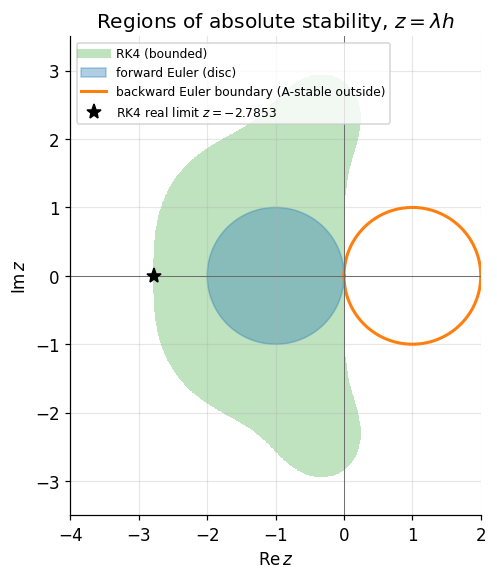

RK4 real-axis stability limit: -2.785293563405282
|R(-2.7)| = 0.8788375000000004  |R(-2.9)| = 1.187170833333333


In [9]:
theta = np.linspace(0, 2 * np.pi, 600)
circle = np.exp(1j * theta)
z_fe = circle - 1.0                 # boundary of |1 + z| = 1
z_be = 1.0 - 1.0 / circle           # boundary of |1 - z| = 1

gx = np.linspace(-4.0, 2.0, 700)
gy = np.linspace(-3.5, 3.5, 700)
X, Y = np.meshgrid(gx, gy)
Z = X + 1j * Y
rk4_region = (np.abs(R(Z)) <= 1.0).astype(float)

fig, ax = plt.subplots(figsize=(6.0, 5.4))
ax.contourf(X, Y, rk4_region, levels=[0.5, 1.5], colors=["C2"], alpha=0.30)
ax.plot([], [], color="C2", lw=6, alpha=0.30, label="RK4 (bounded)")
ax.fill(z_fe.real, z_fe.imag, color="C0", alpha=0.35, label="forward Euler (disc)")
ax.plot(z_be.real, z_be.imag, color="C1", lw=2.0,
        label="backward Euler boundary (A-stable outside)")
ax.axhline(0, color="0.4", lw=0.6)
ax.axvline(0, color="0.4", lw=0.6)
ax.plot([-2.785293563], [0.0], "k*", ms=10, label=r"RK4 real limit $z=-2.7853$")
ax.set_xlim(-4.0, 2.0)
ax.set_ylim(-3.5, 3.5)
ax.set_xlabel(r"$\mathrm{Re}\,z$")
ax.set_ylabel(r"$\mathrm{Im}\,z$")
ax.set_title(r"Regions of absolute stability, $z=\lambda h$")
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print("RK4 real-axis stability limit:", -2.785293563405282)
print("|R(-2.7)| =", abs(R(-2.7)), " |R(-2.9)| =", abs(R(-2.9)))

Forward Euler's region is the unit disc about $-1$, so for $\dot y = \lambda y$ with $\lambda \lt 0$ real it demands $h \le 2/\lvert\lambda\rvert$ — the stiffness trap of Theorem 4.14. Backward Euler's region is everything outside the unit disc about $+1$, which contains the whole left half-plane: A-stable, no step restriction. RK4 buys a larger region than Euler and reaches $z = -2.7853$ on the negative real axis, but it is still bounded, so it is still explicit and still stiffness-limited.

**Figure 3.** The Lotka–Volterra phase portrait of Theorem 4.13: the vector field, four orbits, and the level curves of the first integral $H$ they must lie on.

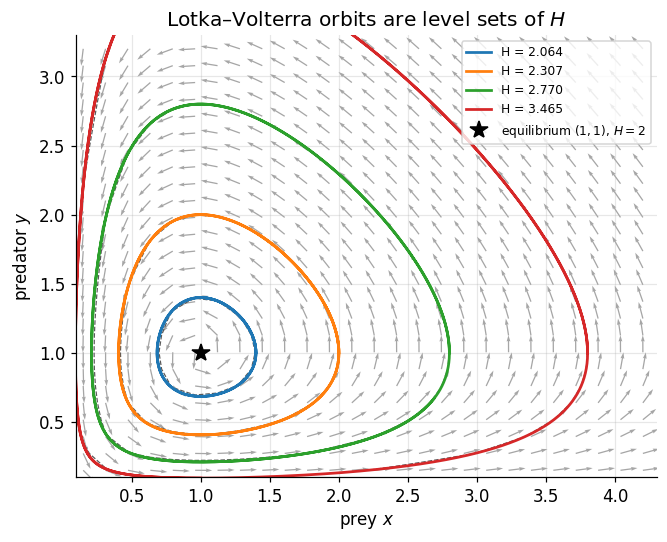

In [10]:
xs = np.linspace(0.15, 4.2, 26)
ys = np.linspace(0.15, 3.2, 26)
XX, YY = np.meshgrid(xs, ys)
U = XX * (1 - YY)
V = YY * (XX - 1)
speed = np.hypot(U, V)

fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.quiver(XX, YY, U / speed, V / speed, color="0.65", angles="xy",
          scale=34, width=0.0022, headwidth=3)

Hgrid = H(XX, YY)
levels = [H(x, 1.0) for x in (1.4, 2.0, 2.8, 3.8)]
ax.contour(XX, YY, Hgrid, levels=sorted(levels), colors="0.35",
           linewidths=0.8, linestyles="dashed")

for x_start, color in zip((1.4, 2.0, 2.8, 3.8), ("C0", "C1", "C2", "C3")):
    s = solve_ivp(lv, [0, 14], [x_start, 1.0], dense_output=True,
                  rtol=1e-11, atol=1e-13)
    tt2 = np.linspace(0, 14, 3000)
    ax.plot(*s.sol(tt2), color=color, lw=1.8,
            label=f"H = {H(x_start, 1.0):.3f}")

ax.plot([1.0], [1.0], "k*", ms=12, label=r"equilibrium $(1,1)$, $H=2$")
ax.set_xlim(0.1, 4.3)
ax.set_ylim(0.1, 3.3)
ax.set_xlabel("prey $x$")
ax.set_ylabel("predator $y$")
ax.set_title(r"Lotka–Volterra orbits are level sets of $H$")
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

Each solid orbit closes on itself and coincides with a dashed level curve of $H$, which is Theorem 4.13 drawn rather than argued. The orbits nest around $(1,1)$, where $H$ attains its strict minimum $2$; larger $H$ means a larger cycle, so the amplitude is set once and for all by the initial condition and never decays. Nothing spirals in or out — a centre that survives the nonlinearity, precisely the case Theorem 4.11 declines to cover.

## 8. Applications

### 8.1 Physics: oscillators and circuits

The damped, driven oscillator

$$
m\ddot{x} + c\dot{x} + kx = F_0\cos(\omega t)
$$

is the constant-coefficient equation of Theorem 4.6 with forcing. Its homogeneous part is classified entirely by the discriminant: with $\omega_0 = \sqrt{k/m}$ and damping ratio $\zeta = c/(2\sqrt{mk})$, the roots are real and distinct for $\zeta \gt 1$ (overdamped), real and repeated for $\zeta = 1$ (critically damped, the fastest non-oscillatory return), and complex for $\zeta \lt 1$ (underdamped, ringing at $\omega_d = \omega_0\sqrt{1-\zeta^2}$). Theorem 4.8 supplies the particular solution for any forcing, and the steady-state amplitude peaks at $\omega_r = \omega_0\sqrt{1-2\zeta^2}$ when $\zeta \lt 1/\sqrt{2}$.

The same equation, with $L, R, 1/C$ in place of $m, c, k$ and charge in place of displacement, is the series RLC circuit; the current amplitude peaks where the reactance cancels, at $\omega = 1/\sqrt{LC}$.

The undamped pendulum $\ddot\theta + (g/L)\sin\theta = 0$ is the standard illustration of why Theorem 4.11 is stated with a hyperbolicity hypothesis: at $(\theta,\dot\theta) = (0,0)$ the linearisation is a centre with $\tau = 0$, and only the conserved energy $E = \tfrac12\dot\theta^2 - (g/L)\cos\theta$ — a first integral in the sense of Definition 3.7 — proves the nonlinear orbits are closed. At $(\pi, 0)$ the linearisation is a saddle, which is hyperbolic, so there Theorem 4.11 does apply.

### 8.2 Machine learning: residual networks and neural ODEs

A residual block updates its hidden state by

$$
h_{l+1} = h_l + f(h_l, \theta_l),
$$

which is exactly one forward Euler step (Theorem 4.14) of $\dot h = f(h,\theta)$ with $h = 1$. Depth plays the role of time, and the network is a discretised flow.

Neural ODEs take that observation literally and parameterise the vector field instead of the layers:

$$
\frac{dh}{dt} = f(h(t), t, \theta), \qquad h(t_1) = h(t_0) + \int_{t_0}^{t_1} f(h(t),t,\theta)\,dt .
$$

Two facts from this module are load-bearing. First, $f$ must be Lipschitz in $h$ for the forward pass to be well posed — Theorem 4.1 — which is why the trajectories of a Neural ODE never cross and why such a model cannot represent a map that would require crossing. Second, gradients are obtained by solving a second ODE backwards in time. With the adjoint $a(t) = \partial L/\partial h(t)$,

$$
\boxed{\ \frac{da}{dt} = -\left(\frac{\partial f(h(t),t,\theta)}{\partial h}\right)^{\!\top} a(t),\qquad \frac{dL}{d\theta} = -\int_{t_1}^{t_0}\left(\frac{\partial f}{\partial \theta}\right)^{\!\top} a(t)\,dt .\ }
$$

**Interpretation.** The adjoint equation is a linear ODE whose coefficient matrix is the transposed Jacobian of the vector field. The consequence is a constant-memory backward pass: nothing from the forward trajectory needs to be stored, because $h$ can be re-integrated backwards alongside $a$, which is the practical advantage a Neural ODE has over a residual network of the same depth.

### 8.3 Optimization: gradient flow

Gradient descent $w_{k+1} = w_k - \eta\nabla L(w_k)$ is forward Euler with step $\eta$ applied to the **gradient flow** $\dot w = -\nabla L(w)$. Along any solution,

$$
\frac{d}{dt}L(w(t)) = \nabla L(w)^\top \dot w = -\lVert \nabla L(w) \rVert_2^2 \le 0 ,
$$

so $L$ is a Lyapunov function for the flow in the sense of Definition 3.6 (after subtracting its minimum), and Theorem 4.12 turns the descent property into a convergence statement whenever $L$ is radially unbounded with a unique minimiser. For a quadratic $L(w) = \tfrac12 w^\top A w$ with $A \succ 0$ the flow is linear, $w(t) = e^{-At}w_0$ by Theorem 4.9, and $\lVert w(t)\rVert_2 \le e^{-\lambda_{\min}t}\lVert w_0\rVert_2$: exponential convergence at a rate set by the smallest eigenvalue. Discretising it recovers the familiar step-size restriction $\eta \lt 2/\lambda_{\max}$ — which is precisely forward Euler's stability disc from Theorem 4.14 applied to the eigenvalue $-\lambda_{\max}$.

The same discretisation view explains stiffness in training: when $\lambda_{\max}/\lambda_{\min}$ is large the problem is stiff, the explicit method is limited by $\lambda_{\max}$ while progress is governed by $\lambda_{\min}$, and preconditioning is the numerical-analysis answer of changing $A$ rather than shrinking $\eta$.

## 9. Key Takeaways

1. If $f$ is continuous on a rectangle $D$ and Lipschitz in $y$ there, the IVP has exactly one solution on $\lvert t - t_0\rvert \le \min(a, b/M)$, and the Picard iterates reach it at the factorial rate $(L\alpha)^{k+1}/(k+1)!$ (Theorem 4.1).
2. Continuity alone buys existence but not uniqueness: $\dot y = y^{2/3}$, $y(0) = 0$ is solved by both $y\equiv 0$ and $y = t^3/27$ (Theorem 4.3, verified in Section 7).
3. With $p, q$ continuous, $y' + p y = q$ is always solvable in quadrature via $\mu = e^{\int p}$, and $M\,dx + N\,dy = 0$ with $M,N \in C^1$ on a simply connected domain is exact iff $M_y = N_x$ (Theorems 4.4, 4.5).
4. For two solutions of the *same* second-order linear equation with continuous coefficients, the Wronskian is $W(t_0)e^{-\int p}$, hence either nowhere zero or identically zero — a dichotomy that fails for arbitrary function pairs (Theorem 4.7).
5. For any fixed square $A$, $e^{At}$ converges, is invertible, differentiates to $Ae^{At}$, and solves $\dot x = Ax$ uniquely; $e^{A+B} = e^Ae^B$ needs $AB = BA$, which is sufficient but not necessary (Theorem 4.9).
6. A planar linear system is asymptotically stable exactly when $\operatorname{tr}A \lt 0$ and $\det A \gt 0$; when $\operatorname{tr}A = 0$ the fixed point is non-hyperbolic and linearisation decides nothing (Theorems 4.10, 4.11).
7. A positive definite $V$ with $\dot V \le 0$ on a neighbourhood gives Lyapunov stability, strict negativity gives asymptotic stability, and radial unboundedness on $\mathbb{R}^n$ upgrades it to global (Theorem 4.12).
8. For $\alpha,\beta,\gamma,\delta \gt 0$, every Lotka–Volterra orbit in the open positive quadrant is a closed curve — a level set of the strictly convex first integral $H$ — hence periodic, with no orbit converging to coexistence (Theorem 4.13).
9. Forward Euler has global order $1$ and stability disc $\lvert 1+z\rvert \le 1$; RK4 has order $4$ and stability function $\sum_{k\le 4} z^k/k!$; backward Euler has order $1$ and is A-stable, which is why stiff problems are integrated implicitly (Theorem 4.14).

## 10. References

| Source | Where it covers what |
| :--- | :--- |
| Teschl, *Ordinary Differential Equations and Dynamical Systems*, GSM 140 | §2.2 Thm 2.2 (Picard–Lindelöf, the contraction proof); §2.6 Thm 2.19 (Peano, cited in Theorem 4.3); §9.2 Thm 9.9 (Hartman–Grobman, cited in Theorem 4.11); §3.2 (matrix exponential and Jordan form) |
| Arnold, *Ordinary Differential Equations*, 3rd ed. | Ch. 2 §7–8 (vector fields, phase flows, the geometric reading of Section 2); Ch. 4 §22–25 (linear systems and $e^{At}$); Ch. 3 §16 (conservative systems and first integrals) |
| Strogatz, *Nonlinear Dynamics and Chaos*, 2nd ed. | §5.2 (the trace–determinant plane behind Theorem 4.10); §6.3–6.4 (phase portraits, Lotka–Volterra and conserved quantities, Theorem 4.13); §7.6 (Lyapunov functions, Theorem 4.12); Ch. 3 and §8.2 (saddle-node, transcritical, pitchfork and Hopf bifurcations) |
| Boyce & DiPrima, *Elementary Differential Equations*, 11th ed. | §2.1 (integrating factor, Theorem 4.4); §2.6 (exact equations, Theorem 4.5); §3.1–3.4 (characteristic roots, Theorem 4.6); §3.3 Thm 3.3.2 (Abel's identity, Theorem 4.7); §3.6 (variation of parameters, Theorem 4.8) |
| Apostol, *Calculus*, Vol. II, 2nd ed. | §7.1–7.9 (linear systems, the exponential matrix, Cayley–Hamilton computation of $e^{At}$) |
| Hairer, Nørsett & Wanner, *Solving ODEs I*, 2nd ed. | §II.1–II.3 (Runge–Kutta order conditions behind Theorem 4.14); Hairer & Wanner, *Solving ODEs II*, §IV.2–IV.3 (A-stability and stiffness) |
| Chen, Rubanova, Bettencourt & Duvenaud, *Neural Ordinary Differential Equations*, NeurIPS 2018 | §2 and Appendix B (the adjoint sensitivity equation boxed in Section 8.2) |
| He, Zhang, Ren & Sun, *Deep Residual Learning for Image Recognition*, CVPR 2016 | §3.2 (the residual block read as one Euler step in Section 8.2) |